In [1]:
# Allowing dynamic links, hot-reload, to our custom modules
%load_ext autoreload
%autoreload 2

In [2]:
%pwd

'/home/user8/dl-gen-lyrics/sandbox'

In [3]:
import sys
print(sys.version)

3.14.4 (main, Apr 14 2026, 14:26:14) [Clang 22.1.3 ]


In [4]:
import os, re, sys, traceback, csv, random

import numpy as np
import pandas as pd
import sentencepiece as spm
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

os.getcwd()

'/home/user8/dl-gen-lyrics/sandbox'

In [5]:
import generator_core as core
from aspect_teal import Teal
import aspect_teal
from aspect_midnight import Word2Vec_SkipGram, ArrayToDatasetForW2V

In [6]:
from dl_trainer import Trainer

In [7]:
batch_count = 103
genres = {'rap', 'rb', 'pop', 'country', 'rock', 'misc'}
print(genres)
print(batch_count)

{'rap', 'misc', 'pop', 'rock', 'country', 'rb'}
103


In [8]:
total_subset_size = 100000
total_group_size = total_subset_size // len(genres) + 1
max_songs_per_artist = 50

In [9]:
ds_subset = pd.read_csv(os.path.join('temp', 'genius_lyrics_subset.csv'))
display(ds_subset.head())

,Unnamed: 0,title,tag,artist,year,lyrics,id,language
0,123725,In Memory of W. B. Yeats,misc,W. H. Auden,2013,I\n\nHe disappeared in the dead of winter:\nTh...,134446,en
1,2614099,Sthlm City,pop,Rebecca & Fiona,2018,"[Intro]\nI mean, like, it's okay\nOne day, you...",3931557,en
2,2550228,Fallin 2010,pop,Mozhdah,2010,[Verse 1]\nCan you take it easy\nWhile I make ...,3840000,en
3,3539706,Can the Circle Be Unbroken,country,Johnny Cash,1982,I was standing by the window\nOn one cold and ...,5350667,en
4,2650114,Marijuana,pop,Jah Cure,2019,[Intro: Jah Cure]\nOne puff one draw\nFrees th...,3982786,en


In [10]:
teal = Teal(ds_subset)

Loaded Cache for Teal._prepare_ds_data.cached
Loaded Cache for Teal._get_custom_tokens.cached
Loaded Cache for Teal._get_genre_dict.cached
Loaded Cache for Teal._prepare_tfidf.cached


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: temp/lyrics_clean.csv
  input_format: 
  model_prefix: temp/lyrics_sp
  model_type: UNIGRAM
  vocab_size: 16000
  self_test_sample_size: 0
  character_coverage: 0.999
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: <VERSE>
  user_defined_symbols: <STANZA>
  user_defined_symbols: <NEW_LINE>
  user_defined_symbols: <SONG_START>
  user_defined_symbols: <BRIDGE>
  user_defined_symbols: <INTERLUDE>
  user_defined_symbols: <INTRO>
  user_defined_symbols: <SONG_END>
  user_defined_symbols: <CHORUS>
  user_defined_symbols: <HOOK>
  user

Loaded Cache for Teal._prepare_embedder.cached


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

cuda


In [14]:
word2vec = teal.embedder
word2vec

Word2Vec_SkipGram(
  (embeddings): Embedding(16000, 512)
  (linear): Linear(in_features=512, out_features=16000, bias=True)
)

In [24]:
word2vec.trainer.checkpoint_frequency_batch = 10
word2vec.trainer.device = 'cuda'
word2vec.trainer.learning_rate(0.001)

In [25]:
word2vec.trainer.train()

Epoch:  0/ 1    Train Loss: 4.35    TTS: 1.09    ETA: 1139.22
Epoch:  0/ 1    Train Loss: 4.58    TTS: 2.00    ETA: 1135.92
Epoch:  0/ 1    Train Loss: 4.76    TTS: 3.09    ETA: 1134.12
Epoch:  0/ 1    Train Loss: 4.65    TTS: 4.00    ETA: 1132.91
Epoch:  0/ 1    Train Loss: 4.64    TTS: 5.09    ETA: 1131.31
Epoch:  0/ 1    Train Loss: 4.63    TTS: 6.18    ETA: 1129.27
Epoch:  0/ 1    Train Loss: 4.70    TTS: 7.13    ETA: 1136.26
Epoch:  0/ 1    Train Loss: 4.61    TTS: 8.04    ETA: 1134.67
Epoch:  0/ 1    Train Loss: 4.71    TTS: 9.00    ETA: 1139.51
Epoch:  0/ 1    Train Loss: 4.48    TTS: 10.09    ETA: 1136.97
Epoch:  0/ 1    Train Loss: 4.59    TTS: 11.00    ETA: 1135.26
Epoch:  0/ 1    Train Loss: 4.38    TTS: 12.10    ETA: 1133.76
Epoch:  0/ 1    Train Loss: 4.36    TTS: 13.01    ETA: 1132.07
Epoch:  0/ 1    Train Loss: 4.37    TTS: 14.10    ETA: 1130.84
Epoch:  0/ 1    Train Loss: 4.76    TTS: 15.01    ETA: 1129.42
Epoch:  0/ 1    Train Loss: 4.34    TTS: 16.11    ETA: 1127.94
E

In [28]:
try:
    flight = 'Teal._prepare_embedder.cached'
    for file in ['bone', 'pkl']:
        file = os.path.join('temp', f'{flight}.{file}')
        if os.path.exists(file): os.remove(file)
    core.key_cached('cached', lambda: word2vec, group='Teal._prepare_embedder')
    print("Done")
except:
    traceback.print_exc()

Done


In [14]:
# model = aspect_teal.TransformerModel(teal.vocabulary.vocab_size(), {
#     "d_model":512,
#     "n_heads":4,
#     "n_groups":2,
#     "n_layers":4,
#     "pe": "sinusoidal",
#     "norm": "layernorm",
#     "attn": "gqa",
#     "ffn": "gelu"
# }, teal.embedder.embeddings.weight)

In [29]:
try:
    train_language_model = True

    if train_language_model:
        teal.language_model = teal._prepare_language_model()

    print(teal.language_model)
except:
    traceback.print_exc()

TransformerModel(
  (embed): Embedding(16000, 512, padding_idx=0)
  (pe): SinusoidalPE()
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (attn): SimpleGQA(
        (q): Linear(in_features=512, out_features=512, bias=True)
        (k): Linear(in_features=512, out_features=256, bias=True)
        (v): Linear(in_features=512, out_features=256, bias=True)
        (o): Linear(in_features=512, out_features=512, bias=True)
      )
      (ffn): GELUFFN(
        (net): Sequential(
          (0): Linear(in_features=512, out_features=2048, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=2048, out_features=512, bias=True)
        )
      )
    )
  )
  (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=512, out_features=16000, bias=True)
)


In [16]:
# def model_train_step(model, data): 
#     return model(data[0])

# def model_criteria_step(criterion, preds, truth):
#     # print(preds.shape, truth.shape)
#     preds = preds.permute(0, 2, 1)
#     return criterion(preds, truth)


# trainer = Trainer(
#     model=model,
#     train_dataloader=dataloader,
#     epochs=1,
#     # dataset_fraction=1,
#     model_train_step=model_train_step,
#     model_criteria_step=model_criteria_step,
#     record_per_batch_training_loss=True,
#     checkpoint_frequency_batch=2,
# )

# trainer.load_model('model_my_model.pt')

In [38]:
torch.cuda.empty_cache()

In [39]:
trainer = teal.language_model.trainer

In [40]:
# trainer.load_model('model_my_model.pt')

In [41]:
trainer.train()
# # CPU Time: 34 sit

Epoch:  0/ 1    Train Loss: 6.52    TTS: 1.19    ETA: 2372.05
Epoch:  0/ 1    Train Loss: 5.58    TTS: 2.16    ETA: 2399.37
Epoch:  0/ 1    Train Loss: 5.87    TTS: 3.21    ETA: 2469.84
Epoch:  0/ 1    Train Loss: 5.45    TTS: 4.21    ETA: 2473.68
Epoch:  0/ 1    Train Loss: 5.53    TTS: 5.14    ETA: 2564.18
Epoch:  0/ 1    Train Loss: 5.33    TTS: 6.21    ETA: 2478.69
Epoch:  0/ 1    Train Loss: 5.07    TTS: 7.05    ETA: 2424.57
Epoch:  0/ 1    Train Loss: 5.77    TTS: 8.18    ETA: 2399.23
Epoch:  0/ 1    Train Loss: 5.61    TTS: 9.11    ETA: 2388.20
Epoch:  0/ 1    Train Loss: 5.63    TTS: 10.14    ETA: 2348.44
Epoch:  0/ 1    Train Loss: 5.67    TTS: 11.01    ETA: 2331.69
Epoch:  0/ 1    Train Loss: 5.44    TTS: 12.12    ETA: 2319.67
Epoch:  0/ 1    Train Loss: 5.49    TTS: 13.09    ETA: 2324.65
Epoch:  0/ 1    Train Loss: 5.59    TTS: 14.10    ETA: 2335.31
Epoch:  0/ 1    Train Loss: 5.55    TTS: 15.01    ETA: 2330.81
Epoch:  0/ 1    Train Loss: 4.93    TTS: 16.12    ETA: 2319.86
E

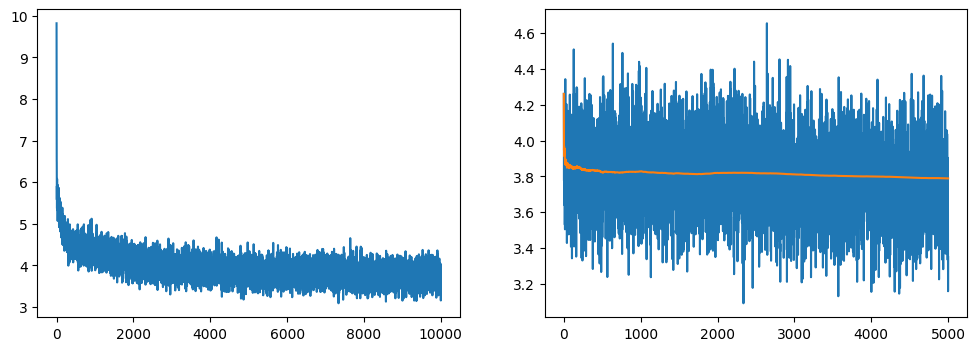

In [42]:
def running_average(nums):
    nums = np.asarray(nums, dtype=float)
    kernel = np.ones(len(nums))
    cumsum = np.convolve(nums, kernel, mode='full')[:len(nums)]
    counts = np.arange(1, len(nums) + 1)
    return cumsum / counts


loss = trainer.loss
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(loss['train.batch'])
axs[1].plot(loss['train.batch'][int(0.5 * len(loss['train.batch'])):])
axs[1].plot(running_average(loss['train.batch'][int(0.5 * len(loss['train.batch'])):]))
plt.show()

In [55]:
try:
    flight = 'Teal._prepare_language_model.cached'
    for file in ['bone', 'pkl']:
        file = os.path.join('temp', f'{flight}.{file}')
        if os.path.exists(file): os.remove(file)
    core.key_cached('cached', lambda: teal.language_model, group='Teal._prepare_language_model')
    print("Saved")
except:
    traceback.print_exc()

Saved


In [58]:
for key in teal.language_model.trainer.timer.timers:
    print(key, trainer.timer.timers[key].average)

In [59]:
try:
    print(teal.inference('rock', ['black', 'enter', 'spell', 'priests', 'dragon'], starting_words='', max_len=400).replace(' <NEW_LINE> ', '\n'))
except:
    traceback.print_exc()

 ⁇  black enter spell priests dragon <SONG_START> we always my dreams
in the rain of the
the green
and when you will meet , you to me to me
thee
i know what can see you at night
and you , you could
ited the , you like love
but your mother see the road has no lie
of a better step
that you never make one more
you know that to the light , let
the door's hardest
the world are you looking for me
well , well
our praises
and our loves of love will come home , come true to me or love
thee in the last to , to the river <SONG_END>
